# RANDOM FOREST

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_california_housing

In [3]:
cali=fetch_california_housing()
X,y=cali.data, cali.target
feature_name=cali.feature_names

OGGETTO REGRESSORE

In [4]:
rf_regressor=RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42
)
rf_regressor.fit(X,y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


importanza delle feature

In [5]:
importance=rf_regressor.feature_importances_
indices=np.argsort(importance)[::-1]

plot delle importanze

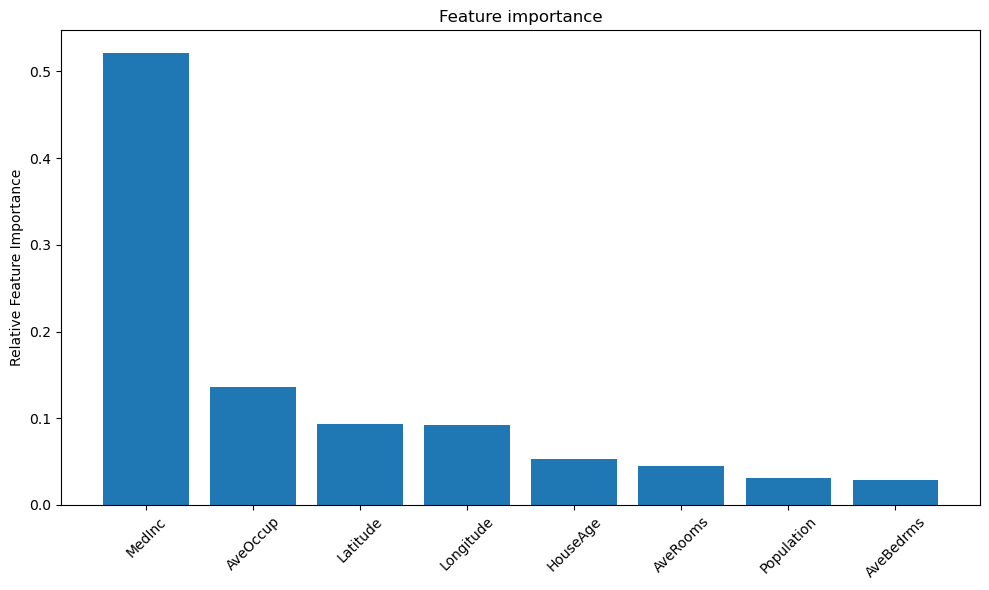

In [6]:
plt.figure(figsize=(10,6))
plt.title("Feature importance")
plt.bar(range(X.shape[1]),importance[indices],align="center")
plt.xticks(range(X.shape[1]),np.array(feature_name)[indices],rotation=45,ha="center")
plt.ylabel("Relative Feature Importance")
plt.tight_layout()
plt.show()


In [8]:
print(f"Importanza Feature")
for i in range(5):
    print(f"{i + 1} - {feature_name[indices[i]]}:\t{importance[indices[i]]:.3f}")

Importanza Feature
1 - MedInc:	0.521
2 - AveOccup:	0.136
3 - Latitude:	0.093
4 - Longitude:	0.093
5 - HouseAge:	0.053


Visualizzo gli alberi

Total Estimator: [DecisionTreeRegressor(max_depth=20, max_features=1.0, random_state=1608637542), DecisionTreeRegressor(max_depth=20, max_features=1.0, random_state=1273642419), DecisionTreeRegressor(max_depth=20, max_features=1.0, random_state=1935803228), DecisionTreeRegressor(max_depth=20, max_features=1.0, random_state=787846414), DecisionTreeRegressor(max_depth=20, max_features=1.0, random_state=996406378), DecisionTreeRegressor(max_depth=20, max_features=1.0, random_state=1201263687), DecisionTreeRegressor(max_depth=20, max_features=1.0, random_state=423734972), DecisionTreeRegressor(max_depth=20, max_features=1.0, random_state=415968276), DecisionTreeRegressor(max_depth=20, max_features=1.0, random_state=670094950), DecisionTreeRegressor(max_depth=20, max_features=1.0, random_state=1914837113), DecisionTreeRegressor(max_depth=20, max_features=1.0, random_state=669991378), DecisionTreeRegressor(max_depth=20, max_features=1.0, random_state=429389014), DecisionTreeRegressor(max_dep

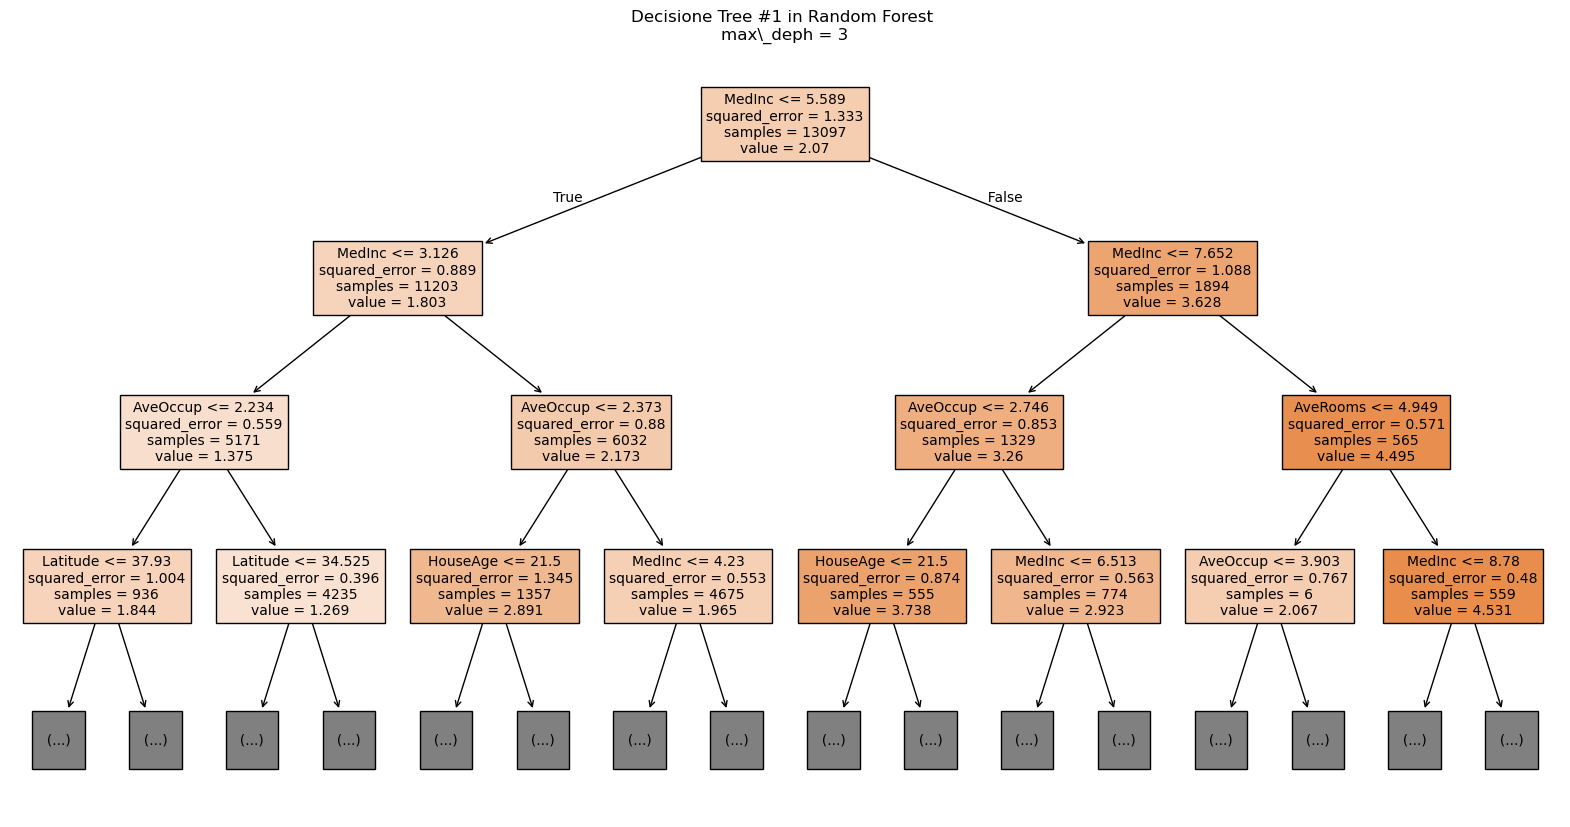

In [14]:
tree_num=0
max_depth=3
estimator=rf_regressor.estimators_[tree_num]
print(f"Total Estimator: {rf_regressor.estimators_}")
plt.figure(figsize=(20,10))
plot_tree(
    estimator,
    feature_names=feature_name,
    max_depth=max_depth,
    filled=True,
    fontsize=10,
)
plt.title(f"Decisione Tree #{tree_num+1} in Random Forest \nmax\\_deph = {max_depth}")
plt.show()

Predizione delle label

In [15]:
y_pred=rf_regressor.predict(X)

grafico

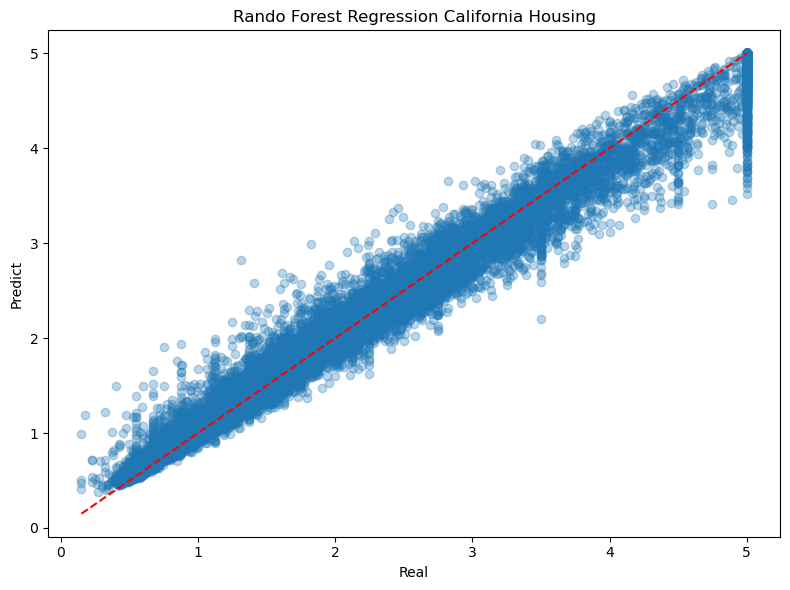

In [16]:

plt.figure(figsize=(8,6))
plt.scatter(y,y_pred,alpha=0.3)
plt.plot([y.min(),y.max()],[y.min(),y.max()],'r--')
plt.xlabel("Real")
plt.ylabel("Predict")
plt.title("Rando Forest Regression California Housing")
plt.tight_layout()
plt.show()

Misura di quanto è stato preciso

In [17]:
err=np.abs(y-y_pred)
tot=0.2*y.mean()
good_pred=np.sum(err<tot)
out=good_pred/len(y)*100
print(f"Prediction (within 20% from average) {out:.2f}")

Prediction (within 20% from average) 95.12


Errore medio

In [18]:
mean_err=np.mean(np.abs(y-y_pred)/y)
print(f"Mean Error: {mean_err*100:.2f}%")

Mean Error: 7.16%
